# Thesis 2024 - 2025
## UGBS
### Isil Oral

* Project on green gentrification in Vienna through social status index, green spaces, blue areas, and housing prices

## Part 5 - WHO Theory

In [1]:
from shapely.geometry import box, Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling
import osmnx as ox  
import contextily as ctx
from geopy.geocoders import Nominatim  
from geopy.extra.rate_limiter import RateLimiter
import os
#!pip install h3
import h3
import matplotlib.patches as mpatches
import seaborn as sns

In [2]:
# Get the current working directory
current_path = os.getcwd()

# Define relative paths for data, output, and helper functions
data_in = os.path.join(current_path, "data")       # Folder with input data
output = os.path.join(current_path, "output")      # Folder for saving results
df_dir = os.path.join(current_path, "dataframes")

In [3]:
# Load any dataframe from that folder
admin_city = gpd.read_file(os.path.join(df_dir, "admin_city_vienna.geojson"))
urban_green_spaces =gpd.read_file(os.path.join(df_dir, "urban_green_spaces.geojson"))
urban_blue_spaces = gpd.read_file(os.path.join(df_dir, "urban_blue_spaces.geojson"))
ugbs_socioecon_census = gpd.read_file(os.path.join(df_dir, "ugbs_socioecon_census.geojson"))
socioecon_districts = gpd.read_file(os.path.join(df_dir, "socioecon_districts.geojson"))
housingprices_district = gpd.read_file(os.path.join(df_dir, "housingprices_district.geojson"))
social_housing = pd.read_csv(os.path.join(df_dir, "social_housing.csv"))
social_housing_gdf = gpd.read_file(os.path.join(df_dir, "social_housing.geojson"))
aptfeatures_social_census = pd.read_csv(os.path.join(df_dir, "aptfeatures_social_census.csv"))
apt_features_final_census = pd.read_csv(os.path.join(df_dir, "apt_features_final_census.csv"))
airbnb_entireunits_gdf = gpd.read_file(os.path.join(df_dir, "airbnb_entireunits.geojson"))
annual_airbnb_gdf = gpd.read_file(os.path.join(df_dir, "annual_airbnb_entire.geojson"))

Skipping field ways: unsupported OGR type: 1
Skipping field amenities: unsupported OGR type: 5
Skipping field amenities: unsupported OGR type: 5


### WHO Theory Explanation

In [4]:
# all residential buildings
residential_tags = {'building': ["apartment", 'terrace', "detached", "annexe", "house", "residential", "semidetached_house"]}
residential = ox.features_from_place('Vienna, Austria', tags=residential_tags)

print("Number of residential buildings:", len(residential))
residential.head()

Number of residential buildings: 29638


created_by                   geometry addr:city  \
element_type osmid                                                        
node         3050128807        NaN   POINT (16.45262 48.2404)      Wien   
             3191378969        NaN  POINT (16.28469 48.18459)      Wien   
             3191378970        NaN  POINT (16.28475 48.18473)      Wien   
             3220013168        NaN   POINT (16.47623 48.2135)      Wien   
             3220013171        NaN  POINT (16.47638 48.21381)      Wien   

                        addr:country addr:housenumber addr:postcode  \
element_type osmid                                                    
node         3050128807           AT              NaN          1220   
             3191378969           AT               39          1130   
             3191378970           AT               41          1130   
             3220013168           AT              7/5          1220   
             3220013171           AT              7/1          1220   

                                addr:street local_ref amenity  \
element_type osmid                                              
node         3050128807       Pogrelzstraße       NaN     NaN   
             3191378969  Münichreiterstraße       NaN     NaN   
             3191378970  Münichreiterstraße       NaN     NaN   
             3220013168      Stavangergasse       NaN     NaN   
             3220013171      Stavangergasse       NaN     NaN   

                        check_date:opening_hours  ... addr:block  \
element_type osmid                                ...              
node         3050128807                      NaN  ...        NaN   
             3191378969                      NaN  ...        NaN   
             3191378970                      NaN  ...        NaN   
             3220013168                      NaN  ...        NaN   
             3220013171                      NaN  ...        NaN   

                        bicycle_parking ways type attraction description:en  \
element_type osmid                                                            
node         3050128807             NaN  NaN  NaN        NaN            NaN   
             3191378969             NaN  NaN  NaN        NaN            NaN   
             3191378970             NaN  NaN  NaN        NaN            NaN   
             3220013168             NaN  NaN  NaN        NaN            NaN   
             3220013171             NaN  NaN  NaN        NaN            NaN   

                        location wikipedia:en building:architecture  \
element_type osmid                                                    
node         3050128807      NaN          NaN                   NaN   
             3191378969      NaN          NaN                   NaN   
             3191378970      NaN          NaN                   NaN   
             3220013168      NaN          NaN                   NaN   
             3220013171      NaN          NaN                   NaN   

                        building:part  
element_type osmid                     
node         3050128807           NaN  
             3191378969           NaN  
             3191378970           NaN  
             3220013168           NaN  
             3220013171           NaN  

[5 rows x 158 columns]

In [5]:
crs_proj = 31256

# Clean geometry and reproject everything to a common projected CRS (EPSG:31256)
residential = residential[residential.is_valid & ~residential.is_empty]
vienna_gdf_proj = admin_city.to_crs(epsg=crs_proj)
residential_proj = residential.to_crs(epsg=crs_proj)
socialhousing_proj = social_housing_gdf.to_crs(epsg=crs_proj)
annual_airbnb_proj = annual_airbnb_gdf.to_crs(epsg=crs_proj)
ugs_proj = urban_green_spaces.to_crs(epsg=crs_proj)
ubs_proj = urban_blue_spaces.to_crs(epsg=crs_proj)

# Clip residential and green and blue areas to Vienna boundary
residential_vienna = gpd.clip(residential_proj, vienna_gdf_proj)
ugs_vienna = gpd.clip(ugs_proj, vienna_gdf_proj)
ubs_vienna = gpd.clip(ubs_proj, vienna_gdf_proj)
airbnb_vienna = gpd.clip(annual_airbnb_proj, vienna_gdf_proj)

In [6]:
print(ugs_vienna.type)
ugs_vienna.head(3)

0            Polygon
1            Polygon
2            Polygon
3            Polygon
4            Polygon
            ...     
1883    MultiPolygon
1884         Polygon
1886         Polygon
1885         Polygon
1887         Polygon
Length: 1888, dtype: object


,id,OBJECTID,T_TEXT,T_LANG,F_TYP,circumference,area,geometry
0,OEFFGRUENFLOGD.3203,3203,Kellerberg Liesing,Kellerberg Liesing,L,3639.130056,252272.443774,"POLYGON ((-1458.691 331297.976, -1459.813 3312..."
1,OEFFGRUENFLOGD.2935,2935,Kellerberg Liesing,Kellerberg Liesing,L,3550.454846,139775.046918,"POLYGON ((-1608.779 331472.048, -1853.519 3314..."
2,OEFFGRUENFLOGD.3327,3327,Auf der Schanz,Auf der Schanz,L,748.705565,10111.920974,"POLYGON ((-2480.719 331926.338, -2480.55 33192..."


In [7]:
# Calculate centroids of residential buildings
res_centroids = residential_vienna.copy()
res_centroids['geometry'] = res_centroids.geometry.centroid

# Calculate centroids of social housings
social_centroids = socialhousing_proj.copy()
social_centroids['geometry'] =social_centroids.geometry.centroid

# Calculate centroids of Airbnbs
airbnb_centroids = airbnb_vienna.copy()
airbnb_centroids['geometry'] = airbnb_centroids.geometry.centroid

In [8]:
# Calculate distance to closest ugs
res_centroids['distance_to_ugs'] = res_centroids.geometry.apply(
    lambda x: ugs_vienna.geometry.distance(x).min()
)
social_centroids['distance_to_ugs'] = social_centroids.geometry.apply(
    lambda x: ugs_vienna.geometry.distance(x).min()
)
airbnb_centroids['distance_to_ugs'] = airbnb_centroids.geometry.apply(
    lambda x: ugs_vienna.geometry.distance(x).min()
)

In [9]:
# Calculate distance to closest ubs
res_centroids['distance_to_ubs'] = res_centroids.geometry.apply(
    lambda x: ubs_vienna.geometry.distance(x).min()
)
social_centroids['distance_to_ubs'] = social_centroids.geometry.apply(
    lambda x: ubs_vienna.geometry.distance(x).min()
)
airbnb_centroids['distance_to_ubs'] = airbnb_centroids.geometry.apply(
    lambda x: ubs_vienna.geometry.distance(x).min()
)

In [10]:
# Combine UGS and UBS into a single GeoDataFrame with types 
ugs_copy = ugs_vienna[['geometry', 'F_TYP']].copy()
ubs_copy = ubs_vienna[['geometry']].copy()
ubs_copy['F_TYP'] = 'B'  # Label blue spaces as 'B'

ugbs_all = pd.concat([ugs_copy, ubs_copy], ignore_index=True)
ugbs_all.set_crs(res_centroids.crs, inplace=True)

,geometry,F_TYP
0,"POLYGON ((-1458.691 331297.976, -1459.813 3312...",L
1,"POLYGON ((-1608.779 331472.048, -1853.519 3314...",L
2,"POLYGON ((-2480.719 331926.338, -2480.55 33192...",L
3,"POLYGON ((-1485.281 331919.746, -1540.031 3319...",L
4,"POLYGON ((-2379.146 331930.698, -2393.698 3319...",L
...,...,...
2897,"POLYGON ((3361.447 350857.731, 3359.637 350856...",B
2898,"POLYGON ((3328.49 350938.597, 3327.541 350937....",B
2899,"POLYGON ((3905.666 351406.961, 3911.716 351424...",B
2900,"POLYGON ((5150.657 352565.523, 5159.216 352566...",B


In [11]:
# For all residential centroids
# Step 1: Assign building_id BEFORE sjoin_nearest (for matching later)
res_centroids = residential_vienna.copy()
res_centroids['building_id'] = res_centroids.index
res_centroids['geometry'] = res_centroids.geometry.centroid  # ensure using centroids

# Step 2: sjoin_nearest for residential
res_centroids = gpd.sjoin_nearest(
    res_centroids, ugbs_all[['geometry', 'F_TYP']],
    how="left", distance_col="distance_to_ugbs"
)
res_centroids['within_300m'] = res_centroids['distance_to_ugbs'] <= 300
res_centroids.rename(columns={"F_TYP": "closest_ugbs_type"}, inplace=True)

# Step 3: Merge back the flag
res_with_flag = residential_vienna.copy()
res_with_flag['building_id'] = res_with_flag.index

res_with_flag = res_with_flag.merge(
    res_centroids[['building_id', 'within_300m']],
    on='building_id', how='left'
)

print(res_centroids.columns.to_list())
print(res_with_flag.columns.to_list())

['created_by', 'geometry', 'addr:city', 'addr:country', 'addr:housenumber', 'addr:postcode', 'addr:street', 'local_ref', 'amenity', 'check_date:opening_hours', 'name', 'opening_hours:signed', 'phone', 'operator', 'operator:wikidata', 'operator:wikipedia', 'addr:unit', 'contact:website', 'cuisine', 'indoor_seating', 'opening_hours', 'outdoor_seating', 'addr:flats', 'wheelchair', 'description', 'ele', 'source', 'at_bev:addr_date', 'building', 'website', 'check_date', 'office', 'historic', 'wikimedia_commons', 'addr2:housenumber', 'addr2:street', 'denomination', 'religion', 'note', 'barrier', 'shop', 'survey:date', 'craft', 'fax', 'addr3:housenumber', 'addr3:street', 'fixme', 'addr:housename', 'power', 'substation', 'tourism', 'wikidata', 'height', 'level', 'building:levels', 'roof:shape', 'layer', 'start_date', 'email', 'image', 'nodes', 'roof:levels', 'diet:vegetarian', 'heritage', 'heritage:operator', 'nohousenumber', 'ref:at:bda', 'roof:colour', 'alt_name', 'castle_type', 'short_name'

In [12]:
# For Airbnb centroids
airbnb_centroids = airbnb_centroids.copy()
airbnb_centroids['building_id'] = airbnb_centroids.index
airbnb_centroids['geometry'] = airbnb_centroids.geometry.centroid  # ensure using centroids

airbnb_centroids = gpd.sjoin_nearest(
    airbnb_centroids, ugbs_all[['geometry', 'F_TYP']],
    how="left", distance_col="distance_to_ugbs"
)
airbnb_centroids['within_300m'] = airbnb_centroids['distance_to_ugbs'] <= 300
airbnb_centroids.rename(columns={"F_TYP": "closest_ugbs_type"}, inplace=True)

# Step 3:
airbnb_with_flag = airbnb_centroids.copy()

In [13]:
print(airbnb_centroids['closest_ugbs_type'].value_counts())
print(airbnb_centroids.columns.to_list())
print(airbnb_with_flag.columns.to_list())

closest_ugbs_type
L    6894
R     863
B     630
U      66
Name: count, dtype: int64
['id', 'price_20250305', 'review_20250305', 'price_20241212', 'review_20241212', 'price_20240911', 'review_20240911', 'price_20240615', 'review_20240615', 'avg_price', 'avg_review', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type_grouped', 'property_type', 'bathrooms', 'bedrooms', 'geometry', 'distance_to_ugs', 'distance_to_ubs', 'building_id', 'index_right', 'closest_ugbs_type', 'distance_to_ugbs', 'within_300m']
['id', 'price_20250305', 'review_20250305', 'price_20241212', 'review_20241212', 'price_20240911', 'review_20240911', 'price_20240615', 'review_20240615', 'avg_price', 'avg_review', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type_grouped', 'property_type', 'bathrooms', 'bedrooms', 'geometry', 'distance_to_ugs', 'distance_to_ubs', 'building_id', 'index_right', 'closest_ugbs_type', 'distance_to_ugbs', 'within_300m']


In [14]:
# For social centroids
social_centroids = social_centroids.copy()
social_centroids['building_id'] = social_centroids.index
social_centroids['geometry'] = social_centroids.geometry.centroid  # ensure using centroids

social_centroids = gpd.sjoin_nearest(
    social_centroids, ugbs_all[['geometry', 'F_TYP']],
    how="left", distance_col="distance_to_ugbs"
)
social_centroids['within_300m'] = social_centroids['distance_to_ugbs'] <= 300
social_centroids.rename(columns={"F_TYP": "closest_ugbs_type"}, inplace=True)

# Step 3: 
soc_with_flag = social_centroids.copy()

print(social_centroids.columns.to_list())
print(soc_with_flag.columns.to_list())

['Hofname', 'clean_address', 'Wohnungen', 'Lokale', 'addr_key', 'geometry', 'distance_to_ugs', 'distance_to_ubs', 'building_id', 'index_right', 'closest_ugbs_type', 'distance_to_ugbs', 'within_300m']
['Hofname', 'clean_address', 'Wohnungen', 'Lokale', 'addr_key', 'geometry', 'distance_to_ugs', 'distance_to_ubs', 'building_id', 'index_right', 'closest_ugbs_type', 'distance_to_ugbs', 'within_300m']


In [16]:
# Output stats for All ugbs:
# Use the merged versions to ensure correct lengths and alignment
total = len(res_with_flag)
within_all = res_with_flag['within_300m'].sum()
within_social = soc_with_flag['within_300m'].sum()
within_airbnb = airbnb_with_flag['within_300m'].sum()

percent_all = (within_all / total) * 100 if total > 0 else 0
percent_social = (within_social / len(soc_with_flag)) * 100 if len(soc_with_flag) > 0 else 0
percent_airbnb = (within_airbnb / len(airbnb_with_flag)) * 100 if len(airbnb_with_flag) > 0 else 0


print("WHO 300m Rule for Vienna:")
print(f"Total residential building number: {total}")
print(f"Municipal estate number:{len(soc_with_flag)}")
print(f"Airbnb entire units number:{len(airbnb_with_flag)}")
print(f"Within 300m of green space: {within_all}")
print(f"Social Housing Within 300m of ugbs: {within_social}")
print(f"Airbnb Within 300m of ugbs: {within_airbnb}")
print(f"Percentage compliant (for all) with WHO guideline: {percent_all:.2f}%")
print(f"Percentage compliant (for social housing) with WHO guideline: {percent_social:.2f}%")
print(f"Percentage compliant (for Airbnbs) with WHO guideline: {percent_airbnb:.2f}%")

# save the output
with open("output/who_300m_summary.txt", "w") as f:
    f.write("WHO 300m Rule for Vienna:\n")
    f.write(f"Total residential building number: {total}\n")
    f.write(f"Municipal estate number: {len(social_centroids)}\n")
    f.write(f"Airbnb entire units number: {len(airbnb_centroids)}\n")
    f.write(f"Within 300m of green space: {within_all}\n")
    f.write(f"Social Housing Within 300m of ugbs: {within_social}\n")
    f.write(f"Airbnb Within 300m of ugbs: {within_airbnb}\n")
    f.write(f"Percentage compliant (for all) with WHO guideline: {percent_all:.2f}%\n")
    f.write(f"Percentage compliant (for social housing) with WHO guideline: {percent_social:.2f}%\n")
    f.write(f"Percentage compliant (for Airbnbs) with WHO guideline: {percent_airbnb:.2f}%")

WHO 300m Rule for Vienna:
Total residential building number: 29659
Municipal estate number:1622
Airbnb entire units number:8453
Within 300m of green space: 27976
Social Housing Within 300m of ugbs: 1594
Airbnb Within 300m of ugbs: 8281
Percentage compliant (for all) with WHO guideline: 94.33%
Percentage compliant (for social housing) with WHO guideline: 98.27%
Percentage compliant (for Airbnbs) with WHO guideline: 97.97%


In [20]:
res_centroids.to_file("dataframes/residential_centroids.geojson", layer='residential', driver="GeoJSON")
res_with_flag.to_file("dataframes/residential_centroids_flagged300m.geojson", layer='residential', driver="GeoJSON")
soc_with_flag.to_file("dataframes/social_centroids_300m.geojson", layer='social_housing', driver="GeoJSON")
airbnb_with_flag.to_file("dataframes/airbnb_centroids_300m.geojson", layer='airbnb', driver="GeoJSON")

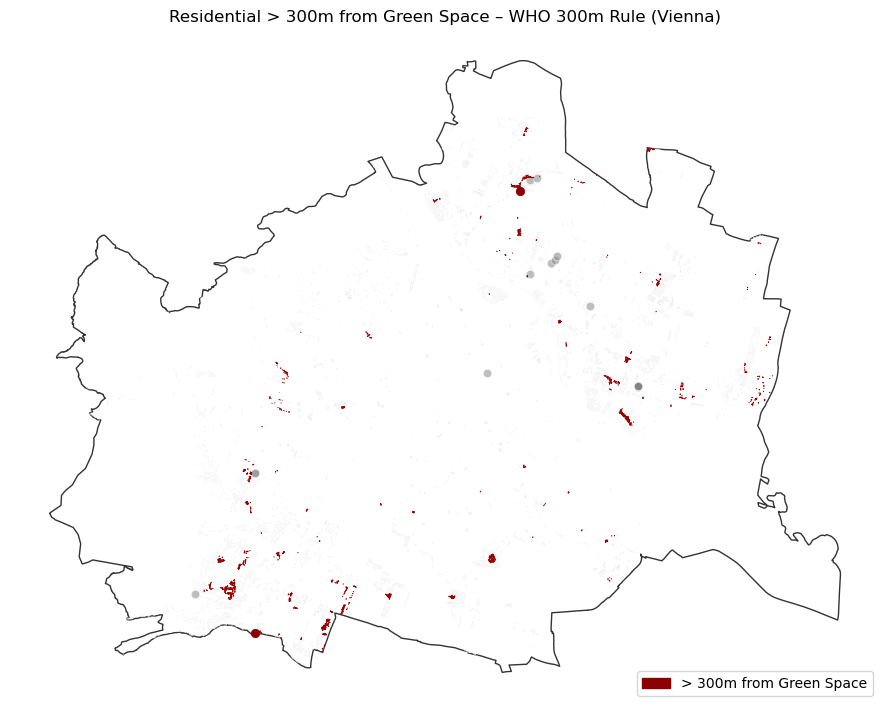

In [17]:
# Get non-compliant buildings
# non_compliant_residential = residential_vienna[~res_centroids['within_300m'].values]
# Now you can safely filter:
non_compliant_residential = res_with_flag[~res_with_flag['within_300m']]

# Create the plot
fig, ax = plt.subplots(figsize=(9, 9))

# Plot layers
vienna_gdf_proj.plot(ax=ax, color='none', edgecolor='#333333')  # Outline
residential_vienna.plot(ax=ax, color='grey', alpha=0.5, edgecolor='white', linewidth=0.6) # Residential buildings
non_compliant_residential.plot(ax=ax, color='darkred', edgecolor='#990000', linewidth=0.6)  # Non-compliant

# Legend
legend_patch = mpatches.Patch(color='darkred', label='> 300m from Green Space')
plt.legend(handles=[legend_patch], loc='lower right')

# Title and export
plt.title("Residential > 300m from Green Space – WHO 300m Rule (Vienna)", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig("output/who_300m_noncompliant_all_legend.png", dpi=300, bbox_inches='tight')
plt.show()

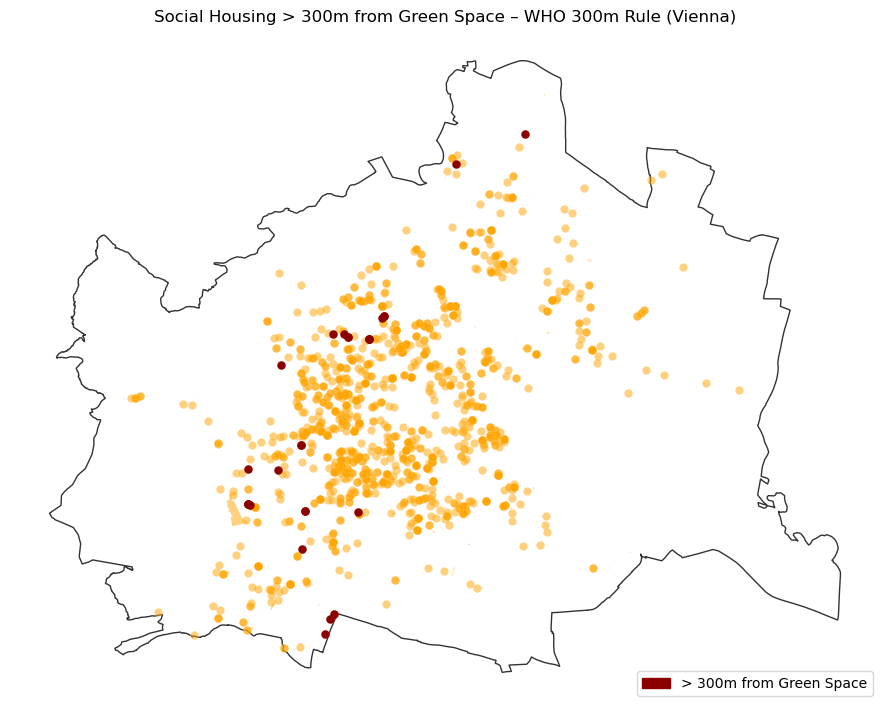

In [18]:
# Get non-compliant social housing 
non_compliant_social = soc_with_flag[~soc_with_flag['within_300m']]

# Create the plot
fig, ax = plt.subplots(figsize=(9, 9))

# Plot layers
vienna_gdf_proj.plot(ax=ax, color='none', edgecolor='#333333')  # Outline
socialhousing_proj.plot(ax=ax, color='orange', alpha=0.5, edgecolor='white', linewidth=0.1) # Social housings
non_compliant_social.plot(ax=ax, color='darkred', edgecolor='#990000', linewidth=0.07)  # Non-compliant

# Legend
legend_patch = mpatches.Patch(color='darkred', label='> 300m from Green Space')
plt.legend(handles=[legend_patch], loc='lower right')

# Title and export
plt.title("Social Housing > 300m from Green Space – WHO 300m Rule (Vienna)", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig("output/who_300m_noncompliant_social_legend.png", dpi=300, bbox_inches='tight')
plt.show()

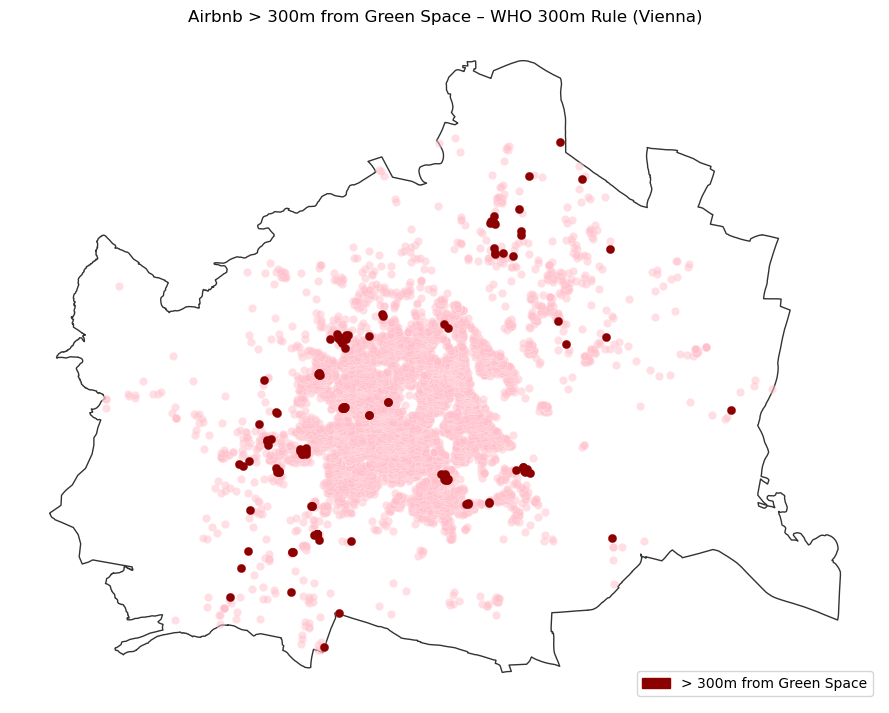

In [19]:
# Get non-compliant Airbnbs
non_compliant_airbnb = airbnb_with_flag[~airbnb_with_flag['within_300m']]

# Create the plot
fig, ax = plt.subplots(figsize=(9, 9))

# Plot layers
vienna_gdf_proj.plot(ax=ax, color='none', edgecolor='#333333')  # Outline
airbnb_vienna.plot(ax=ax, color='pink', alpha=0.5, edgecolor='white', linewidth=0.2) # Airbnb
non_compliant_airbnb.plot(ax=ax, color='darkred', edgecolor='#990000', linewidth=0.2)  # Non-compliant

# Legend
legend_patch = mpatches.Patch(color='darkred', label='> 300m from Green Space')
plt.legend(handles=[legend_patch], loc='lower right')

# Title and export
plt.title("Airbnb > 300m from Green Space – WHO 300m Rule (Vienna)", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig("output/who_300m_noncompliant_airbnb_legend.png", dpi=300, bbox_inches='tight')
plt.show()